In [1]:
from ultralytics import YOLO
import sys
import os
import cv2

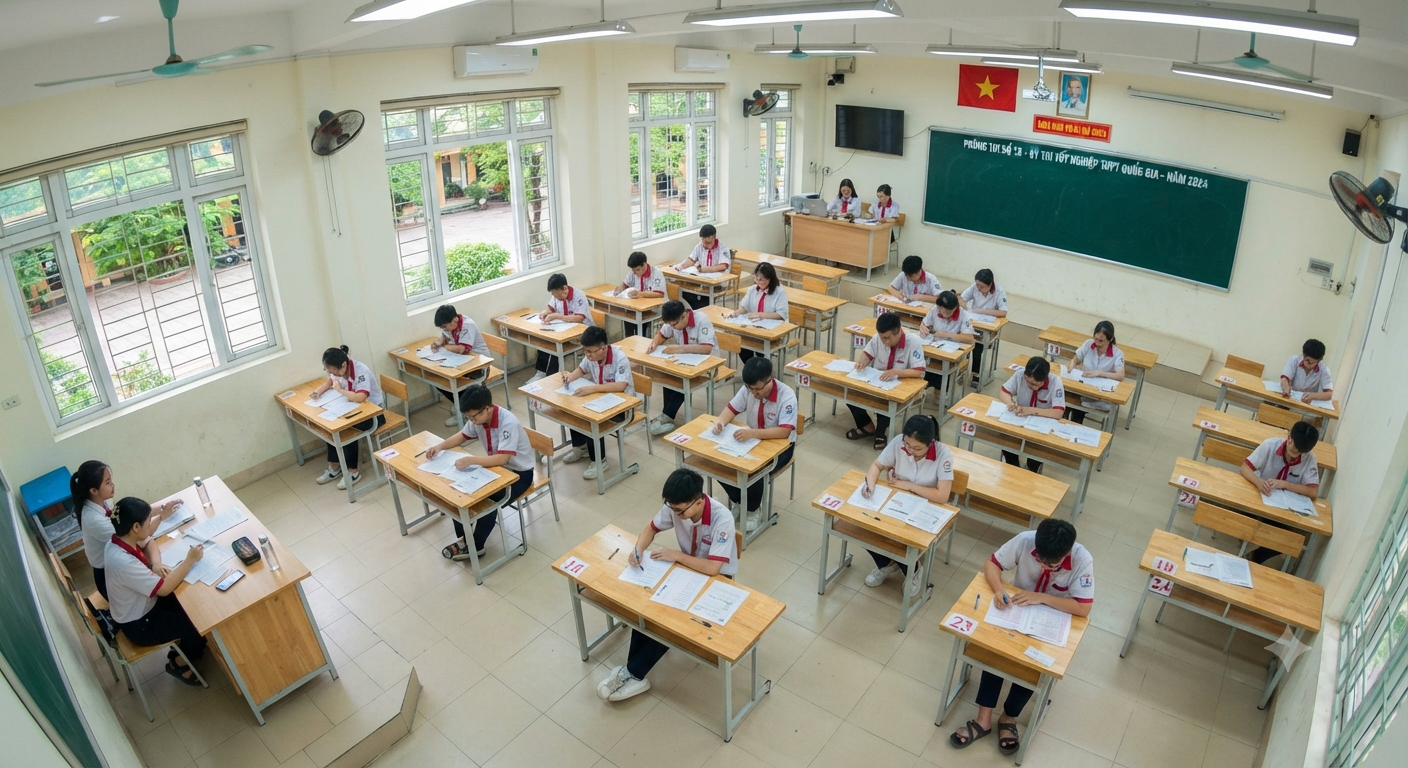

In [2]:
from IPython.display import Image
VIDEO_PATH = '../data/raw/1809.mp4'
IMAGE_PATH = '../data/raw/standard_exam_room.png'

Image(filename=IMAGE_PATH, width=400)

In [3]:
# Go up one directory level from 'notebooks/' to the project root
sys.path.append(os.path.abspath('..'))

# Now you can use absolute imports from the 'src' folder
from src.core.frame import Frame
from src.core.roi import ROI

In [ ]:
pose_model = YOLO("../models/yolo26n-pose.pt")
# results = pose_model(IMAGE_PATH)
# for r in results:
#   if r.keypoints is not None:
#     # Lấy tọa độ các keypoints (shape: [num_people, 17, 3] với 17 khớp xương)
#     kpts = r.keypoints.data

#     for person_kpts in kpts:
#       # Định nghĩa các chỉ số keypoints trong COCO Pose:
#       # 5: Vai trái (Left Shoulder), 6: Vai phải (Right Shoulder)
#       # 9: Cổ tay trái (Left Wrist), 10: Cổ tay phải (Right Wrist)
#       # 11: Hông trái, 12: Hông phải...

#       left_shoulder = person_kpts[5]
#       right_shoulder = person_kpts[6]
#       left_wrist = person_kpts[9]
#       right_wrist = person_kpts[10]

In [5]:
capCam = cv2.VideoCapture(VIDEO_PATH)

if not capCam.isOpened():
  print("Error: Can't open cam or video.")
  exit()

window_name = "Example"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

fps = capCam.get(cv2.CAP_PROP_FPS)
frame_width = int(capCam.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(capCam.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Định nghĩa các cặp điểm (index) sẽ nối với nhau bằng đường line
skeleton_links = [
    (5, 6),  # Vai trái - Vai phải
    (5, 11),  # Vai trái - Hông trái
    (6, 12),  # Vai phải - Hông phải
    (11, 12),  # Hông trái - Hông phải
    (11, 13),  # Hông trái - Đầu gối trái
    (12, 14),  # Hông phải - Đầu gối phải
]

while capCam.isOpened():
  ret, cam_frame = capCam.read()
  if not ret:
    print("CLOSE")
    break

  results = pose_model(cam_frame)

  for r in results:
    if r.keypoints is not None:
      kpts = r.keypoints.data

      for person_kpts in kpts:
        # Lưu lại tọa độ và độ tin cậy của 17 điểm để tiện truy vấn
        # Mỗi điểm là một tensor [x, y, conf]
        points = {}
        for idx in [5, 6, 11, 12, 13, 14]:
          x, y, conf = person_kpts[idx].tolist()
          points[idx] = (int(x), int(y), conf)

        # 1. Vẽ các đường nối (lines) trước để nằm phía dưới các điểm tròn
        for start_idx, end_idx in skeleton_links:
          pt1_x, pt1_y, pt1_conf = points[start_idx]
          pt2_x, pt2_y, pt2_conf = points[end_idx]

          # Chỉ vẽ đường nối nếu cả 2 điểm đầu mút đều có độ tin cậy > 0.5
          if pt1_conf > 0.5 and pt2_conf > 0.5:
            cv2.line(
                cam_frame,
                (pt1_x, pt1_y),
                (pt2_x, pt2_y),
                color=(255, 0, 0),
                thickness=2,
            )  # Đường màu xanh dương

        # 2. Vẽ các chấm tròn (keypoints) lên trên
        for idx, (x, y, conf) in points.items():
          if conf > 0.5:
            cv2.circle(
                cam_frame,
                (x, y),
                radius=5,
                color=(0, 255, 0),
                thickness=-1,
            )  # Chấm màu xanh lá

  # Hiển thị frame
  cv2.imshow(window_name, cam_frame)

  if cv2.waitKey(1) & 0xFF == ord("q"):
    break

# Giải phóng tài nguyên
capCam.release()
cv2.destroyAllWindows()


0: 384x640 4 persons, 73.1ms
Speed: 8.3ms preprocess, 73.1ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 47.9ms
Speed: 2.3ms preprocess, 47.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 50.6ms
Speed: 2.2ms preprocess, 50.6ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 persons, 47.8ms
Speed: 2.1ms preprocess, 47.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 46.9ms
Speed: 2.0ms preprocess, 46.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 51.3ms
Speed: 2.3ms preprocess, 51.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 persons, 48.5ms
Speed: 2.0ms preprocess, 48.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 persons, 43.8ms
Speed: 5.5ms preprocess, 43.8ms inference, 1.3ms postprocess per image at shape (